In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import os, sys
from scipy.optimize import bisect

In [2]:
plt.rcParams["font.family"] = "Manjari"
#bold
plt.rcParams["font.weight"] = "bold"

In [3]:
L = 100.0
Npart = 1e9
nx = 2**(int(round(np.log2(Npart**(1/3))))-1)
dx = L/nx
xvec = np.linspace(0+dx/2, L-dx/2, nx)
print(nx)

spectral_idx = -2.0

freqs = np.fft.fftfreq(nx, d=dx)

kx, ky, kz = np.meshgrid(freqs, freqs, freqs)
k = np.sqrt(kx**2 + ky**2 + kz**2)

densi_tilde = np.random.normal(size=(nx, nx, nx)) + 1j * np.random.normal(size=(nx, nx, nx))
densi_tilde *= k**spectral_idx
densi_tilde[0, 0, 0] = 0.0
densi = np.fft.ifftn(densi_tilde).real

densi -= densi.min()
densi /= densi.sum()
densi *= Npart

512


/tmp/ipykernel_391766/1361807472.py:16: RuntimeWarning: divide by zero encountered in power
  densi_tilde *= k**spectral_idx


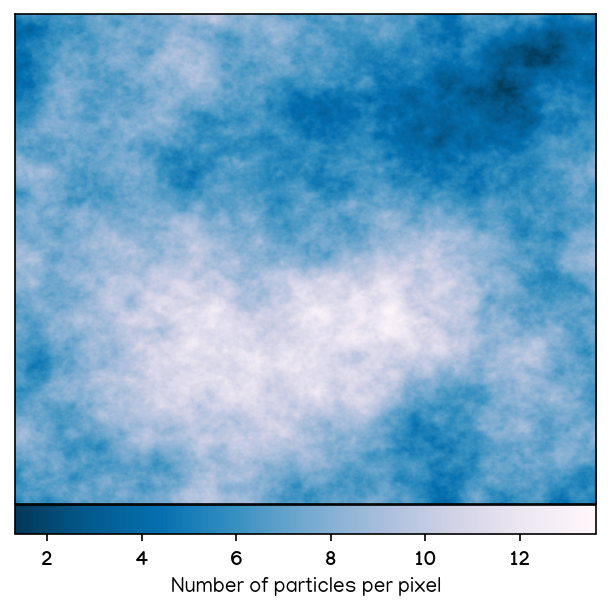

In [4]:
fig, ax = plt.subplots(figsize=(5,5), dpi = 150,)
ax.imshow(densi[:, :, int(nx/2)].T, cmap='PuBu_r', interpolation = 'gaussian', aspect='auto', origin='lower',)
#hide ticks
ax.set_xticks([])
ax.set_yticks([])
#Colorbar attached to the bottom
cbar = fig.colorbar(ax.images[0], ax=ax, orientation='horizontal', pad=0.002, )
cbar.set_label('Number of particles per pixel')
cbar.ax.xaxis.set_label_position('bottom')
plt.savefig('inhomo_dist.pdf', dpi=200, bbox_inches='tight', pad_inches=0.1)


In [5]:
def get_thr(thr, densi, Npart):
    return (densi/thr).astype(int).sum() - Npart
thr = bisect(get_thr, densi.min()+1e-6, densi.max(), args=(densi, Npart))
parts = (densi/thr).astype(int)

In [6]:
parts.sum()

1000000000

(array([1.9710000e+03, 4.0813000e+04, 2.8665700e+05, 1.1312500e+06,
        3.8704990e+06, 1.1267089e+07, 2.3580691e+07, 3.2399242e+07,
        2.7643697e+07, 1.6946642e+07, 9.4974340e+06, 4.6126530e+06,
        1.9364500e+06, 7.7684100e+05, 2.1035800e+05, 1.5436000e+04]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
        10.5, 11.5, 12.5, 13.5, 14.5, 15.5]),
 <BarContainer object of 16 artists>)

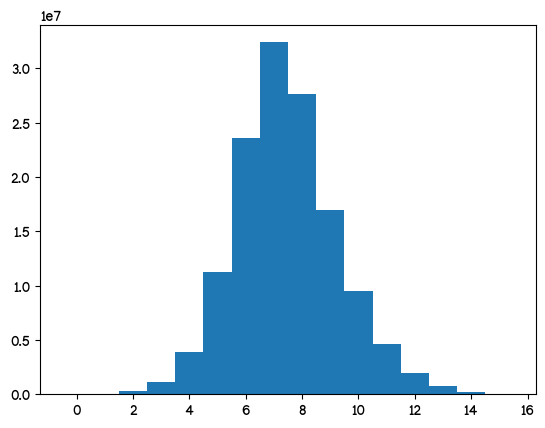

In [7]:
plt.hist(parts.flatten(), bins=np.arange(0,parts.max()+1)-0.5)

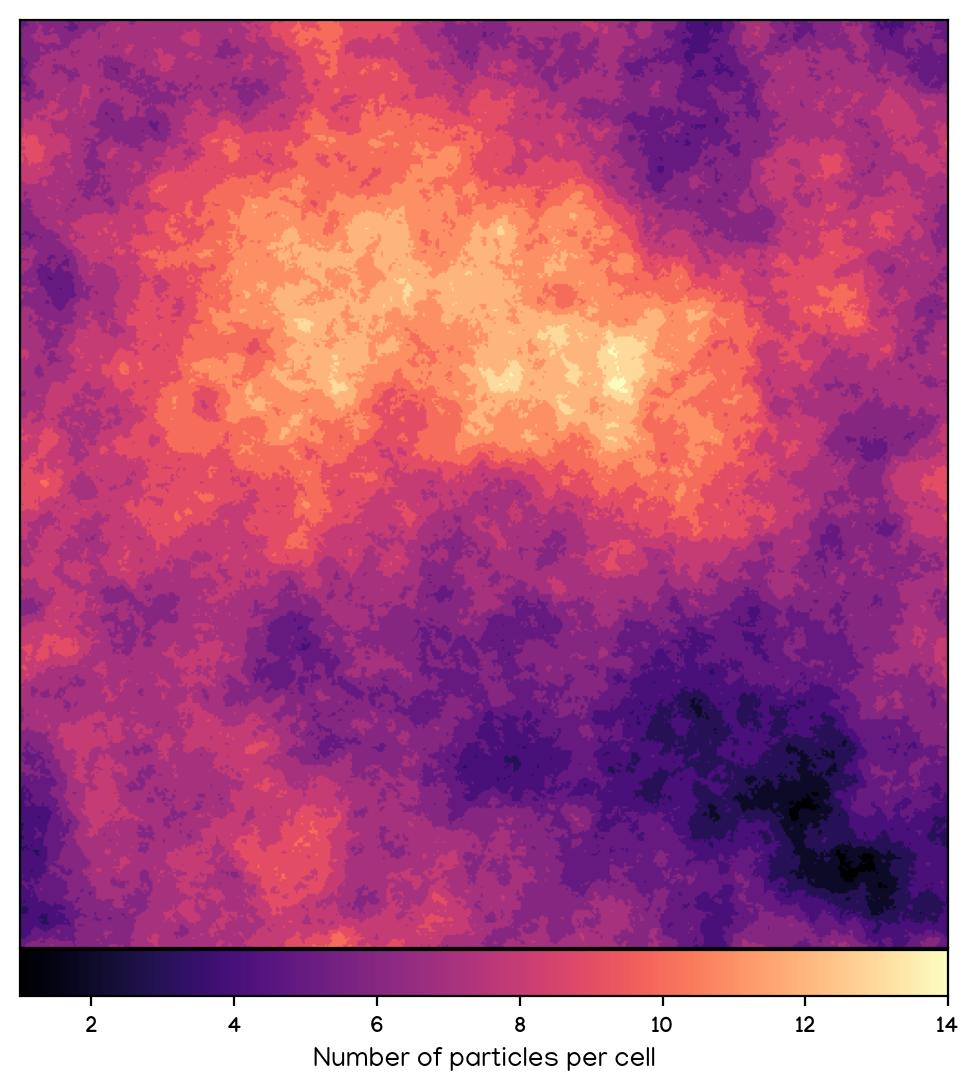

In [8]:
fig, ax = plt.subplots(figsize=(5, 6), dpi = 200)
ax.imshow(parts[:, :, int(nx/2)].T, cmap='magma')
#hide ticks
ax.set_xticks([])
ax.set_yticks([])
#Colorbar attached to the bottom
cbar = fig.colorbar(ax.images[0], ax=ax, orientation='horizontal', pad=0.002, )
cbar.set_label('Number of particles per cell')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()


In [9]:
def get_thr(thr, densi, Npart):
    return (densi/thr).astype(int).sum() - Npart
thr = bisect(get_thr, densi.min()+1e-6, densi.max(), args=(densi, Npart))
parts = (densi/thr).astype(int)

xpart = [] 
ypart = []
zpart = []

for i in range(nx):
    for j in range(nx):
        for k in range(nx):
            npart = parts[i, j, k]
            if npart > 0:
                xpart += [np.random.uniform(xvec[i]-dx/2, xvec[i]+dx/2, npart)]
                ypart += [np.random.uniform(xvec[j]-dx/2, xvec[j]+dx/2, npart)]
                zpart += [np.random.uniform(xvec[k]-dx/2, xvec[k]+dx/2, npart)]

xpart = np.concatenate(xpart)
ypart = np.concatenate(ypart)
zpart = np.concatenate(zpart)

In [13]:
select = (xvec[int(nx/2)]-dx/2<zpart) & (zpart<xvec[int(nx/2)]+dx/2)
if select.sum() > 1e4:
    # subsample only 10000
    true_locs = np.flatnonzero(select)
    selected = np.random.choice(true_locs, size=10000, replace=False)
    select[:] = False
    select[selected] = True
print(select.sum())

10000


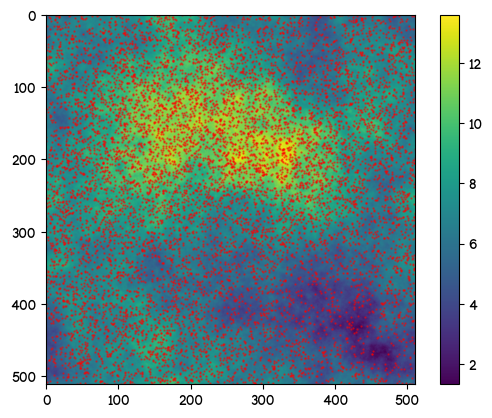

In [14]:
plt.imshow(densi[:, :, int(nx/2)].T, cmap='viridis')
plt.colorbar()
plt.scatter(xpart[select]/dx - 0.5, ypart[select]/dx - 0.5, s=0.5, c='red', alpha=0.5)
#plt.contour(parts[:,:,int(nx/2)], levels=[10])
plt.gca().set_aspect(1)

In [12]:
# # Save particle positions with Scipy.FortranFile
# from scipy.io import FortranFile as FF

# with FF('points.dat', 'w') as f:
#     f.write_record(np.int32(len(xpart)))
#     f.write_record(xpart.astype(np.float32))
#     f.write_record(ypart.astype(np.float32))
#     f.write_record(zpart.astype(np.float32)) 

# Save to npy file
np.save('points_9.npy', np.array([xpart, ypart, zpart], dtype=np.float32).T)


In [ ]:
# #save 1e9 file in 10 files of 1e8
# npart_save = np.int32(1e8)

# for i in range(10):
#     with FF('points_9_'+str(i)+'.dat', 'w') as f:
#         f.write_record(npart_save)
#         f.write_record(xpart[i*npart_save:(i+1)*npart_save].astype(np.float32))
#         f.write_record(ypart[i*npart_save:(i+1)*npart_save].astype(np.float32))
#         f.write_record(zpart[i*npart_save:(i+1)*npart_save].astype(np.float32))
